In [91]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict 
from typing import Literal

In [92]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    descriminant: float
    result: str

In [93]:
def show_equation(state: QuadState) -> QuadState:

    equation = f'{state["a"]}x² + {state["b"]}x + {state["c"]} = 0'
    
    return {'equation': equation}

In [94]:
def calculate_descriminant(state: QuadState):

    descriminant = state["b"]**2 - (4 * state["a"] * state["c"])

    return {'descriminant': descriminant}

In [95]:
def real_roots(state: QuadState):

    root1 = (-state["b"] + state["descriminant"] ** 0.5)/(2 * state["a"])
    root2 = (-state["b"] - state["descriminant"] ** 0.5)/(2 * state["a"])
    result = f'The roots are {root1} and {root2}'

    return {'result': result}


In [96]:
def repeated_roots(state: QuadState):

    root1 = (-state["b"])/(2 * state["a"])
    
    result = f'Only repeating root is {root1}'

    return {'result': result}


In [97]:
def imag_roots(state: QuadState):

    
    result = f'The roots are not real'

    return {'result': result}


In [98]:
#this is routing fxn
def check_condition(state: QuadState)-> Literal["real_roots", "repeated_roots", "imag_roots"]:
    
    if state['descriminant'] > 0:
        return "real_roots"
    elif state['descriminant'] == 0:
        return "repeated_roots"
    else:
        return "imag_roots"

In [99]:
graph = StateGraph(QuadState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_descriminant', calculate_descriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('imag_roots', imag_roots)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_descriminant')
graph.add_conditional_edges('calculate_descriminant', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('imag_roots', END)

workflow = graph.compile()

In [100]:
initial_state = {
    'a': 3,
    'b': 5,
    'c': -1
}

final_state = workflow.invoke(initial_state)
print(final_state)

{'a': 3, 'b': 5, 'c': -1, 'equation': '3x² + 5x + -1 = 0', 'descriminant': 37, 'result': 'The roots are 0.1804604217163699 and -1.8471270883830364'}


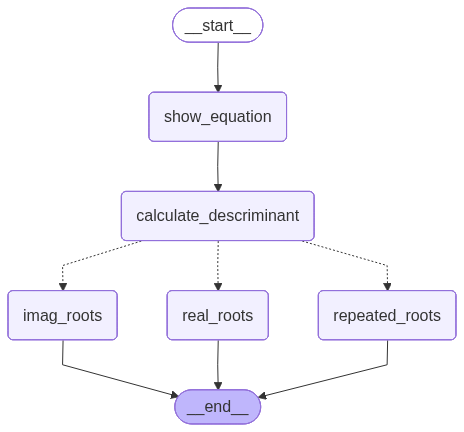

In [101]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())